In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("ICIWstyle")

In [2]:
n_dot = np.load("FBA-E-19032025_250ml-min_2bar_250_TotalSystem_composition.npy")
timestamps = np.load("FBA-E-19032025_250ml-min_2bar_250_TotalSystem_times.npy")

In [23]:
time_delta = timestamps - timestamps[0]

np.savez(
    "FBA-E-19032025_250ml-min_2bar_250_TotalSystem.npz",
    n_dot=n_dot.T,
    time_delta=time_delta,
)

t_range = (time_delta.min(), time_delta.max())

In [18]:
t_offset = 20.25 + 45 * 60 + 5 * 60
t_halfperiod = 300

switching_times = np.full((24,), t_halfperiod)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[ 3020  3320  3620  3920  4220  4520  4820  5120  5420  5720  6020  6320
  6620  6920  7220  7520  7820  8120  8420  8720  9020  9320  9620  9920
 10220]
[(3020, 3320), (3320, 3620), (3620, 3920), (3920, 4220), (4220, 4520), (4520, 4820), (4820, 5120), (5120, 5420), (5420, 5720), (5720, 6020), (6020, 6320), (6320, 6620), (6620, 6920), (6920, 7220), (7220, 7520), (7520, 7820), (7820, 8120), (8120, 8420), (8420, 8720), (8720, 9020), (9020, 9320), (9320, 9620), (9620, 9920), (9920, 10220)]


In [19]:
print(time_delta.shape)
print(n_dot.shape)

(149166,)
(149166, 3)


In [20]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot.T,
    kind="linear",
    fill_value="extrapolate",
)

In [21]:
t = np.linspace(*t_range, 481)
n_dot_interp = interp(t)

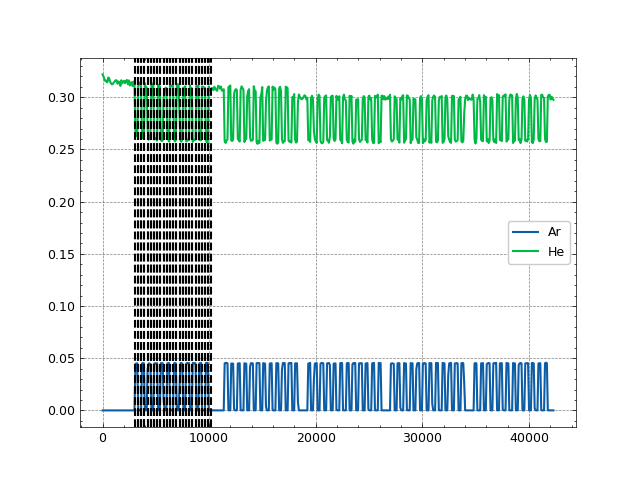

In [22]:
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
for interval in intervals:
    plt.axvline(interval[0], color="black", linestyle="--")
    plt.axvline(interval[1], color="black", linestyle="--")
plt.legend()

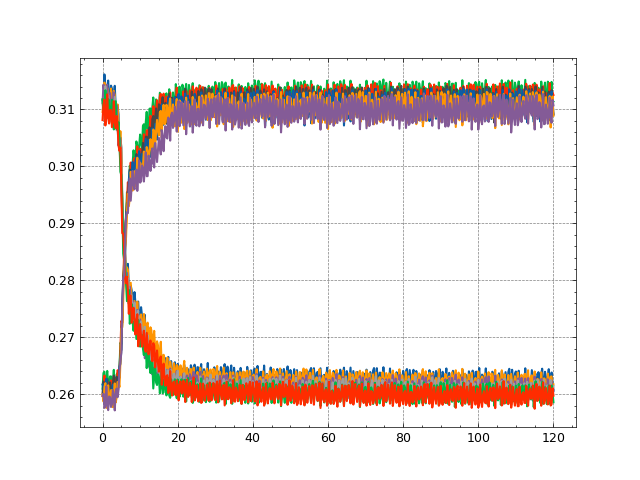

In [17]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 120, 480 + 1)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[1])

In [9]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")
from pathlib import Path
from nRTD.rtd_fitting_5 import RTDDataModule

data_total_system = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-10032025_30ml-min_1atm_TotalSystem.npz"
    ),
    switching_times=switching_times,
    t_range_in=(0, 10),
    n_in=41,
    t_range_out=(0, 120),
    n_out=481,
    switch_delay=1.0,
)

In [10]:
data_total_system.setup("fit")
data_total_system.x[0]

Setup


tensor([[0.0004, 0.0004, 0.0004, 0.0004, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595, 0.0595,
         0.0595, 0.0595, 0.0595, 0.0595, 0.0595]], dtype=torch.float64)

In [11]:
%matplotlib notebook
fig = plt.figure()
index = 0
plt.plot(
    data_total_system.t_in[index],
    data_total_system.x[index].squeeze(),
    ls="--",
)
plt.plot(
    data_total_system.t_in[index + 2],
    data_total_system.x[index + 2].squeeze(),
    ls="--",
)
plt.plot(
    data_total_system.t_out[index],
    data_total_system.y[index].squeeze(),
    "o",
    c="C0",
    markersize=0.5,
)
plt.plot(
    data_total_system.t_out[index + 2],
    data_total_system.y[index + 2].squeeze(),
    "o",
    c="C1",
    markersize=0.5,
)
plt.plot(
    data_total_system.t_in[index + 1],
    data_total_system.x[index + 1].squeeze(),
    ls="--",
    c="C2",
)
plt.plot(
    data_total_system.t_in[index + 3],
    data_total_system.x[index + 3].squeeze(),
    ls="--",
    c="C3",
)
plt.plot(
    data_total_system.t_out[index + 1],
    data_total_system.y[index + 1].squeeze(),
    "o",
    c="C2",
    markersize=0.5,
)
plt.plot(
    data_total_system.t_out[index + 3],
    data_total_system.y[index + 3].squeeze(),
    "o",
    c="C3",
    markersize=0.5,
)
plt.show()

<IPython.core.display.Javascript object>